<a href="https://colab.research.google.com/github/hemantborse/Capstone/blob/main/Credit_Card_Fraud_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, auc
import time
import seaborn as sns


This dataset is from https://www.kaggle.com/code/gpreda/credit-card-fraud-detection-predictive-models

Dataset Information copied from Kaggle -

The datasets contains transactions made by credit cards in September 2013 by european cardholders. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation.

Due to confidentiality issues, there are not provided the original features and more background information about the data.

Features V1, V2, ... V28 are the principal components obtained with PCA;
The only features which have not been transformed with PCA are Time and Amount. Feature Time contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature Amount is the transaction Amount, this feature can be used for example-dependant cost-senstive learning.
Feature Class is the response variable and it takes value 1 in case of fraud and 0 otherwise.

In [3]:
df = pd.read_csv('data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


**Understanding the Features:**
Features V1, V2, ... V28 are the principal components obtained with PCA; The only features which have not been transformed with PCA are Time and Amount. Feature Time contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature Amount is the transaction Amount, this feature can be used for example-dependant cost-senstive learning. Feature Class is the response variable and it takes value 1 in case of fraud and 0 otherwise.


use CRISP DM Model for this assignment


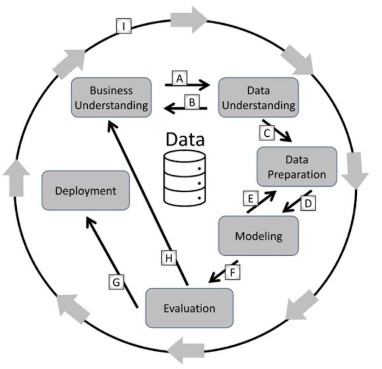

# ============================================================
# PHASE 1: Business Understanding
# ============================================================
# Goal: Detect fraud with maximum recall (≥90%)
# Primary metric: PR-AUC
# Secondary metric: Recall (fraud class)

# ============================================================
# PHASE 2: Data Understanding
# ============================================================


In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,55551.000000,...,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000,55550.000000
mean,30593.297438,-0.242712,-0.003647,0.691422,0.176704,-0.259108,0.101075,-0.117926,0.055073,0.082709,...,-0.028758,-0.107167,-0.038779,0.007005,0.134820,0.020698,0.003723,0.004178,94.706159,0.002808
std,13417.206531,1.874492,1.646638,1.469689,1.390191,1.406023,1.310300,1.263701,1.201861,1.195036,...,0.726547,0.636713,0.591365,0.595828,0.438300,0.499660,0.385969,0.327168,256.951934,0.052919
min,0.000000,-56.407510,-72.715728,-32.965346,-5.172595,-42.147898,-26.160506,-26.548144,-41.484823,-9.283925,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.577118,-8.567638,-9.617915,0.000000,0.000000
25%,24650.000000,-0.995659,-0.576212,0.210839,-0.724377,-0.875414,-0.636850,-0.605745,-0.146478,-0.636440,...,-0.230060,-0.528848,-0.179555,-0.323874,-0.129129,-0.330362,-0.063604,-0.006497,7.680000,0.000000
50%,34700.000000,-0.250987,0.078237,0.788023,0.187527,-0.292173,-0.153096,-0.075137,0.059987,-0.023887,...,-0.065460,-0.082633,-0.051642,0.061907,0.173830,-0.073836,0.008763,0.022443,25.765000,0.000000
75%,40776.000000,1.154616,0.733392,1.420950,1.057956,0.279688,0.491908,0.425462,0.334543,0.764475,...,0.110489,0.307371,0.079145,0.401830,0.421044,0.299391,0.082852,0.076489,87.000000,0.000000
max,47005.000000,1.960497,18.183626,4.101716,16.491217,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,17.297845,4.014444,5.525093,3.517346,11.135740,33.847808,12910.930000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55551 entries, 0 to 55550
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    55551 non-null  int64  
 1   V1      55551 non-null  float64
 2   V2      55551 non-null  float64
 3   V3      55551 non-null  float64
 4   V4      55551 non-null  float64
 5   V5      55551 non-null  float64
 6   V6      55551 non-null  float64
 7   V7      55551 non-null  float64
 8   V8      55551 non-null  float64
 9   V9      55551 non-null  float64
 10  V10     55551 non-null  float64
 11  V11     55551 non-null  float64
 12  V12     55551 non-null  float64
 13  V13     55551 non-null  float64
 14  V14     55551 non-null  float64
 15  V15     55550 non-null  float64
 16  V16     55550 non-null  float64
 17  V17     55550 non-null  float64
 18  V18     55550 non-null  float64
 19  V19     55550 non-null  float64
 20  V20     55550 non-null  float64
 21  V21     55550 non-null  float64
 22

In [6]:
print(df.isna().sum())
df.dropna()
print(df.isna().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


**Business understanding:** The datasets contains transactions made by credit cards, where we have 492 frauds out of 284,807 transactions.We need to train a model which can predict card fraud

In [7]:
#check duplicates : Identify and remove redundant rows that can skew analysis.
df.duplicated().sum()
df.drop_duplicates()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55546,47004,1.283418,0.354874,0.158519,0.607335,-0.186818,-0.865444,0.084609,-0.186195,0.042276,...,-0.310652,-0.887568,0.084508,-0.012270,0.267755,0.116476,-0.022729,0.027233,0.89,0.0
55547,47005,-0.969584,-0.514812,1.010076,-0.492493,-1.074442,0.812377,1.739011,0.069684,-0.741379,...,0.137958,-0.378729,0.989131,-0.311335,-0.302619,0.720578,-0.171671,0.034326,424.80,0.0
55548,47005,-0.448083,0.936043,1.308078,0.424255,0.141240,-0.224215,1.114183,-0.286478,-0.144553,...,0.084264,0.345878,-0.222427,0.052293,0.093368,-0.387899,-0.354380,-0.223041,55.75,0.0
55549,47005,0.616391,-0.770376,-0.306186,1.374006,-0.177289,0.186992,0.417697,0.073573,-0.009001,...,0.182098,-0.039148,-0.409170,-0.315762,0.626198,-0.254219,-0.042365,0.044234,293.00,0.0


# **Exploratory Data Analysis**


1.   **Class Imbalance Barchart**



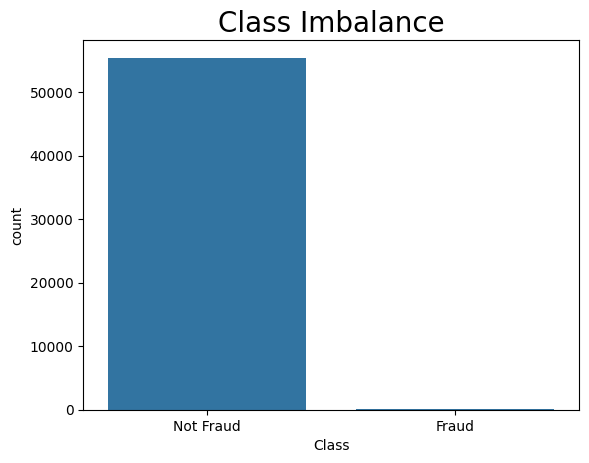

In [8]:
#
sns.countplot(x = 'Class', data = df)
plt.xticks([0, 1], ['Not Fraud', 'Fraud'])
plt.title('Class Imbalance', fontsize = 20)
plt.show()

**2.   Scatter Plot Amount Vs Fraud**






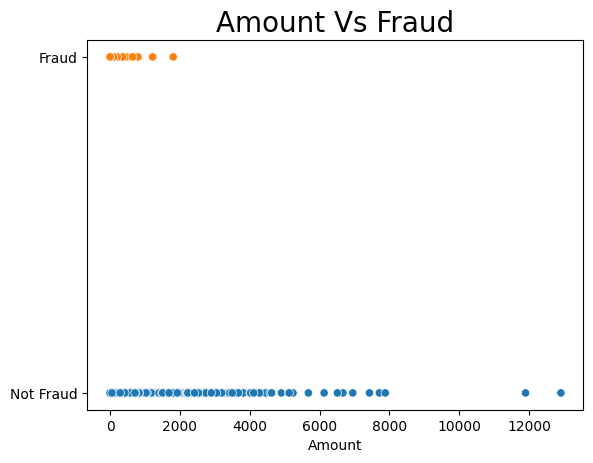

         count       mean         std  min   25%    50%      75%       max
Class                                                                     
0.0    55394.0  94.703197  257.030241  0.0  7.68  25.79  86.9075  12910.93
1.0      156.0  95.758013  228.178528  0.0  1.00   4.93  99.9900   1809.68


In [9]:
y = np.where(df['Class'] == 1, 1, 0)
sns.scatterplot(data = df, x = 'Amount', y =y, hue =y, legend = False)
plt.yticks([0, 1], ['Not Fraud', 'Fraud']);
plt.title('Amount Vs Fraud', fontsize = 20)
plt.show()
fraud_stats = df.groupby('Class')['Amount'].describe()
print(fraud_stats)

**Observation** :
Based on scatter plot above we can see that fraudulant transactions amount is always less than 5000,
 it's also true of 99% of legit transactions

3. Based on above scatterplot lets explore transaction amount destribution by class





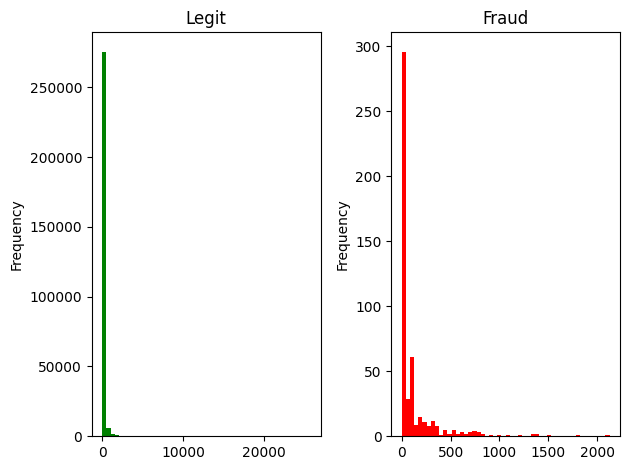

In [27]:

fig,axes = plt.subplots(1,2)
df[df['Class']==0]['Amount'].plot(kind='hist',bins=50,ax=axes[0],title='Legit',color = 'green')
df[df['Class']==1]['Amount'].plot(kind='hist',bins=50,ax=axes[1],title='Fraud',color='red')
plt.tight_layout() #Automatically adjusts subplots so that titles and axis labels do not overlap.
plt.show()

4. Lets explore transaction time destribution by class

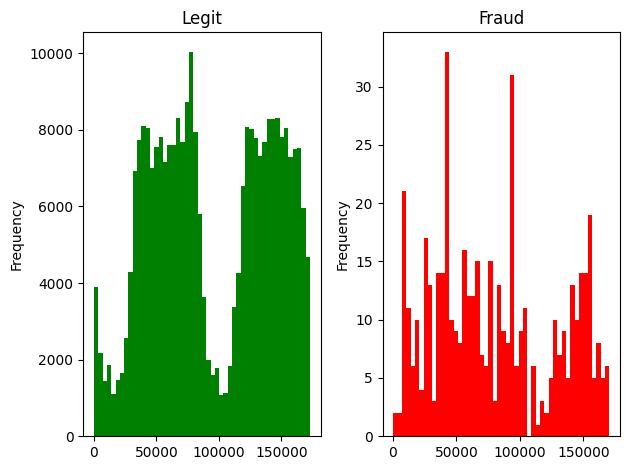

In [28]:

fig,axes = plt.subplots(1,2)
df[df['Class']==0]['Time'].plot(kind='hist',bins=50,ax=axes[0],title='Legit',color = 'green')
df[df['Class']==1]['Time'].plot(kind='hist',bins=50,ax=axes[1],title='Fraud',color='red')
plt.tight_layout()
plt.show()

5. Lets explore Box Plots for V1 to V28 (Fraud Vs Legit)

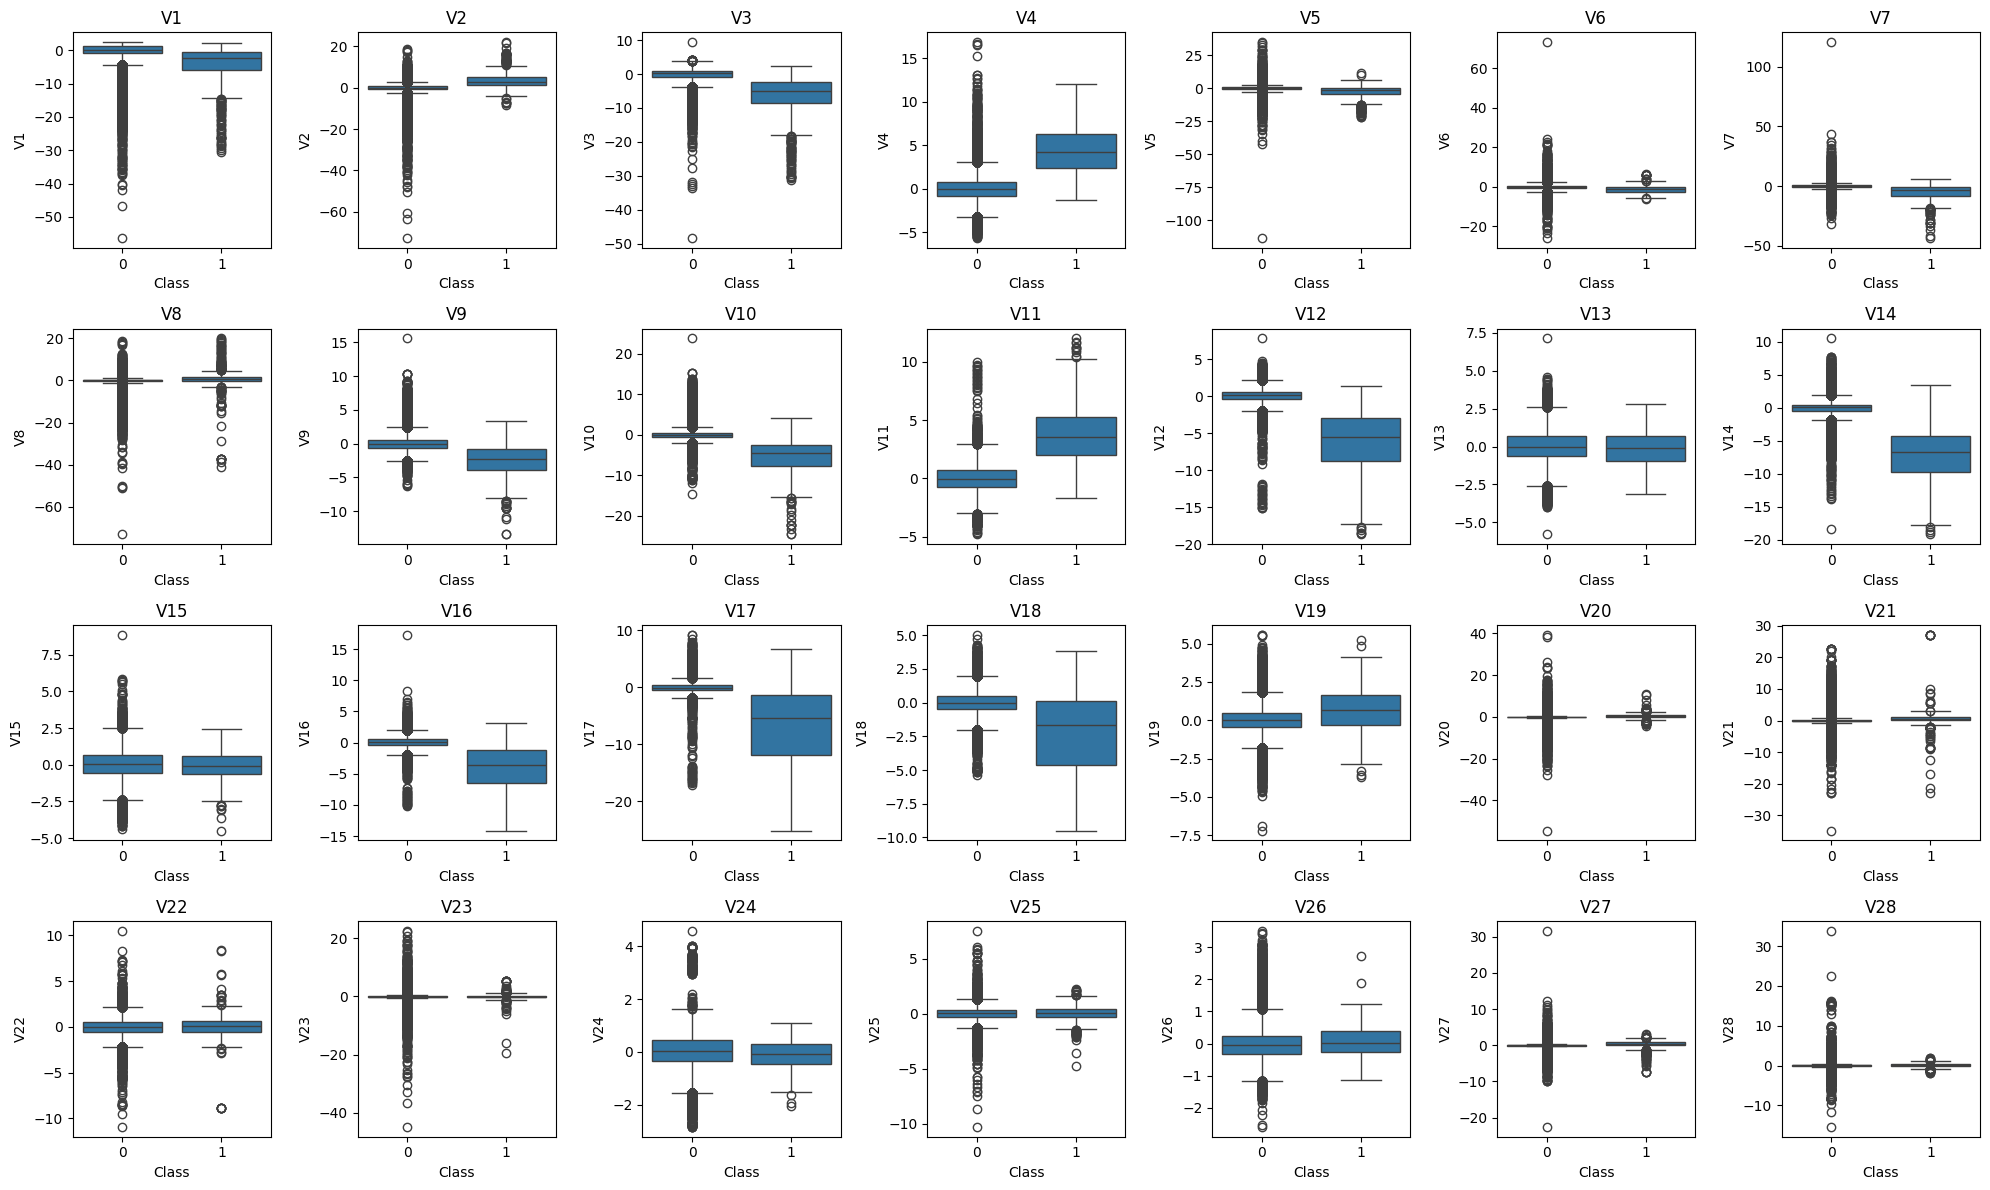

In [29]:
fig,axes = plt.subplots(4,7,figsize=(20,12))
for i, ax in enumerate(axes.flat):
    sns.boxplot(x='Class',y=f'V{i+1}',data=df,ax=ax)
    ax.set_title(f'V{i+1}')
    plt.tight_layout()
plt.show()

**6.Correlation Heatmap**

<Axes: >

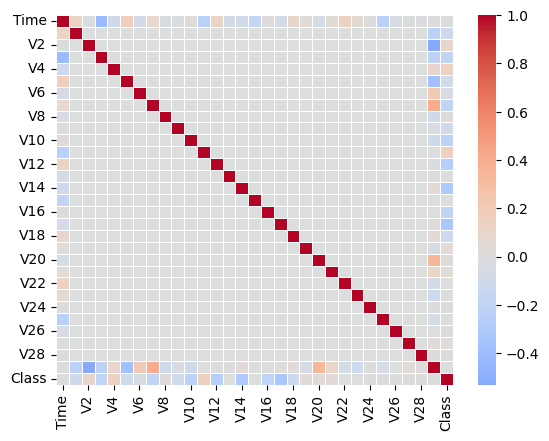

In [30]:
sns.heatmap(df.corr(),cmap='coolwarm',center=0,linewidths=0.5)

**Based on above heatmap, more focused version below which shows only Correlations with the Class Column**

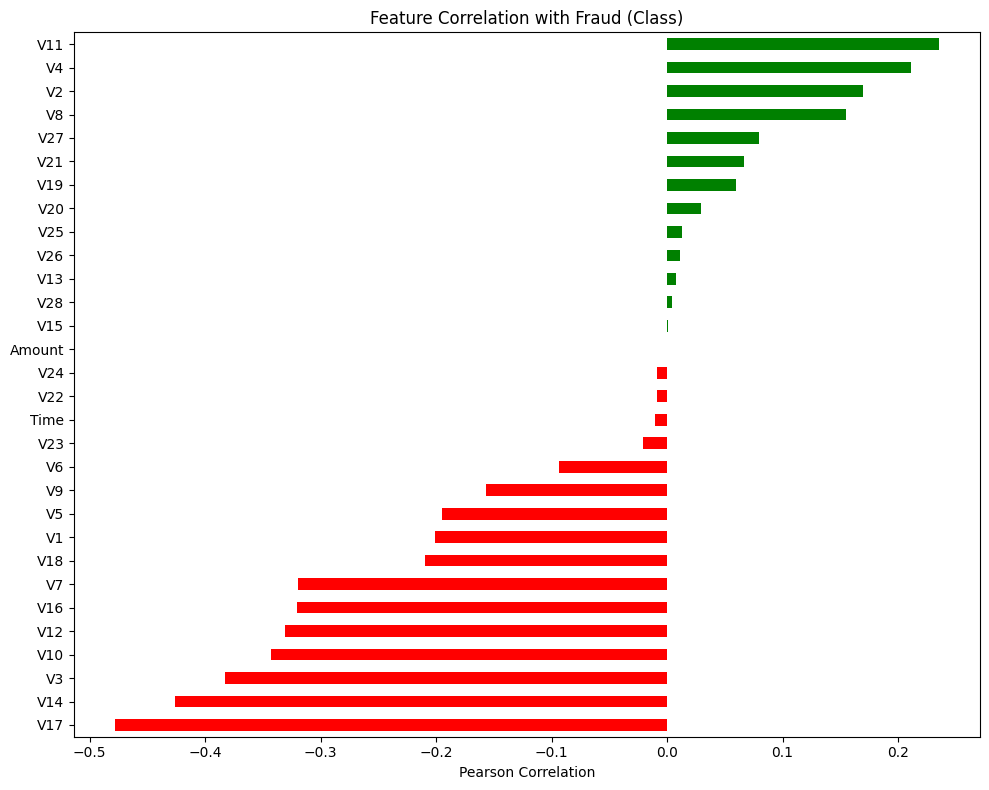

In [10]:
class_corr = df.corr()['Class'].drop('Class').sort_values()
plt.figure(figsize=(10, 8))
class_corr.plot(kind='barh', color=class_corr.map(lambda x: 'red' if x < 0 else 'green'))
plt.title('Feature Correlation with Fraud (Class)')
plt.xlabel('Pearson Correlation')
plt.tight_layout()

**Above correlation heatmap shows V17, V14,V3,V12, V10 are most negatively correlated with fraud**

/tmp/ipykernel_170/3451325521.py:14: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(t0[feature], bw_method=0.5,label="Class = 0")
/tmp/ipykernel_170/3451325521.py:15: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(t1[feature], bw_method=0.5,label="Class = 1")


<Figure size 640x480 with 0 Axes>

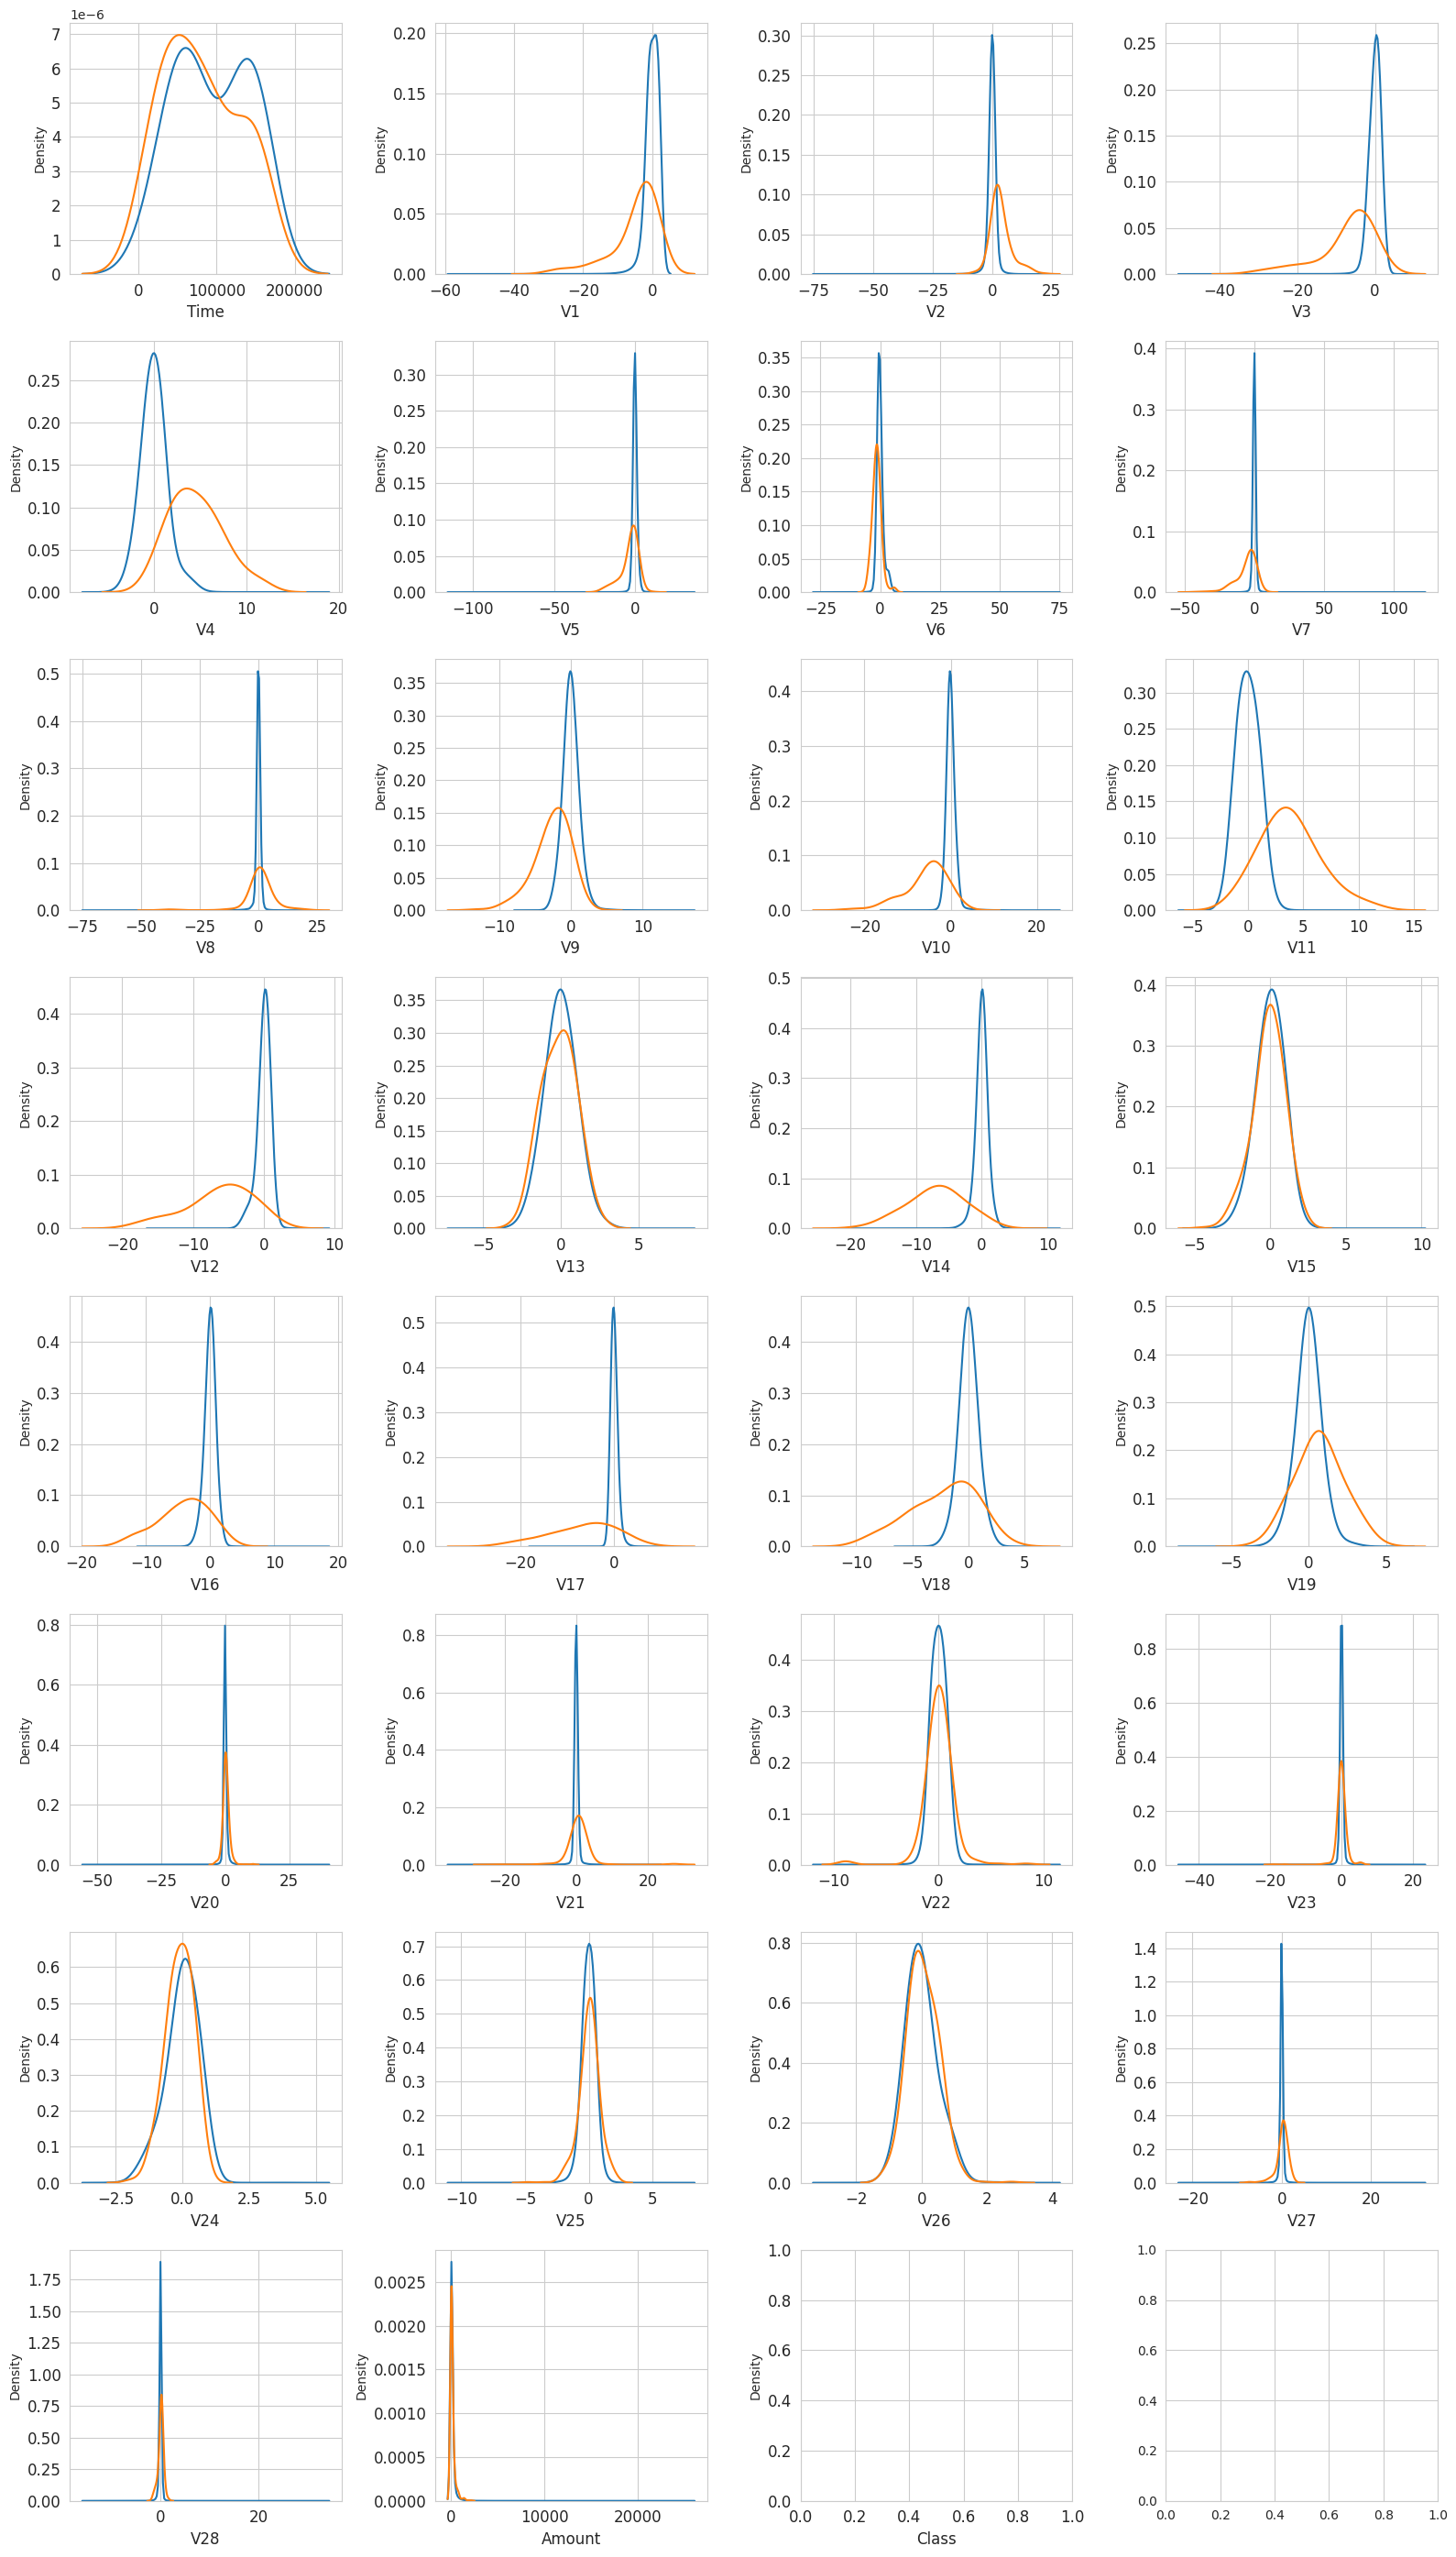

In [61]:
var = df.columns.values

i = 0
t0 = df.loc[df['Class'] == 0]
t1 = df.loc[df['Class'] == 1]

sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(8,4,figsize=(16,28))

for feature in var:
    i += 1
    plt.subplot(8,4,i)
    sns.kdeplot(t0[feature], bw_method=0.5,label="Class = 0")
    sns.kdeplot(t1[feature], bw_method=0.5,label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    locs, labels = plt.xticks()
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.tight_layout()
plt.show();


**distributions for Class values 0 and 1**
*   Class Values V4 and V11  have clearly separated
*   V12, V14, V18 are partially separated
*   V1, V2, V3, V10 have distinct profile
*   V25, V26, V28 have similar profiles







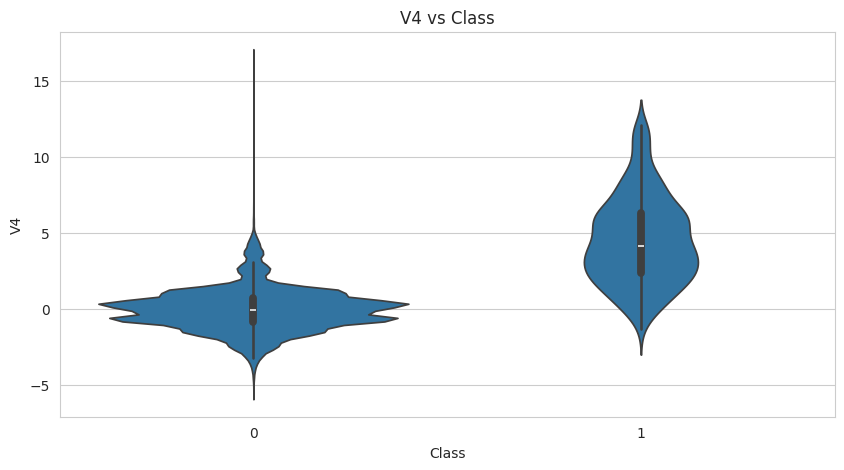

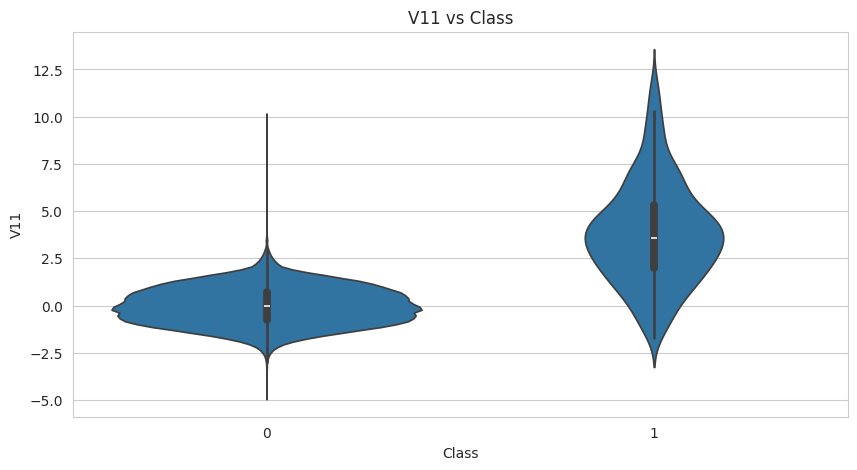

In [62]:
#violin plot
#based on step #5 - top features are V4,V11
t_features=['V4','V11']
for col in t_features:
    plt.figure(figsize=(10,5))
    sns.violinplot(x='Class',y=col,data=df)
    plt.title(f'{col} vs Class')
    plt.show()

<Axes: title={'center': 'Log Amount'}, ylabel='Frequency'>

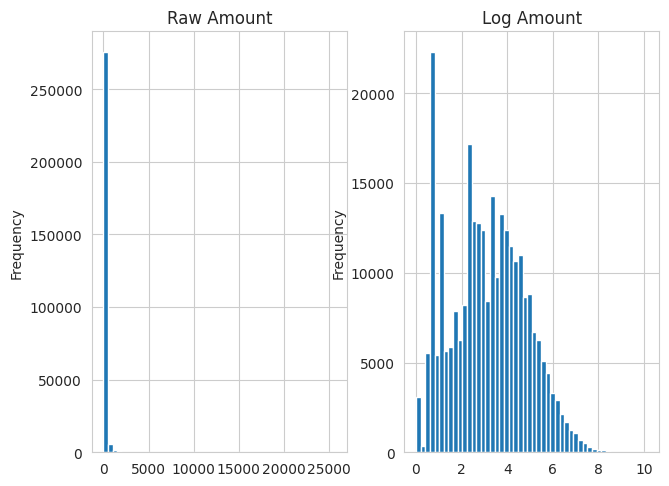

In [63]:
fig,axes = plt.subplots(1,2)
plt.tight_layout()
df['Amount'].plot(kind='hist',bins=50,ax=axes[0],title='Raw Amount')
np.log1p(df['Amount']).plot(kind='hist',bins=50,ax=axes[1],title='Log Amount')

# ============================================================
# PHASE 3: Data Preparation
# ============================================================
# - Handle class imbalance (class_weight='balanced')
# - Scale Amount with StandardScaler
# - Time-based train/test split (no future leakage)

# **Dummy Baseline Classifier**

In [64]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier # Added this import statement
X= df.drop('Class',axis=1)
y= df['Class']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
#Dummy always predicts "not fraud"
Dummy = DummyClassifier(strategy='most_frequent')
Dummy.fit(X_train,y_train)
y_pred = Dummy.predict(X_test)
print (metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Logistic Regression

In [49]:


lrg = Pipeline([('scaler',StandardScaler()),('model',LogisticRegression(class_weight='balanced',random_state=42,max_iter=1000))])
lrg.fit(X_train,y_train)

#print(X_test.isnull().sum())
y_pred = lrg.predict(X_test)
print (metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     85307
           1       0.06      0.93      0.10       136

    accuracy                           0.97     85443
   macro avg       0.53      0.95      0.55     85443
weighted avg       1.00      0.97      0.99     85443



# **Modeling and Evaluation**
Confusion Matrix and Heatmap

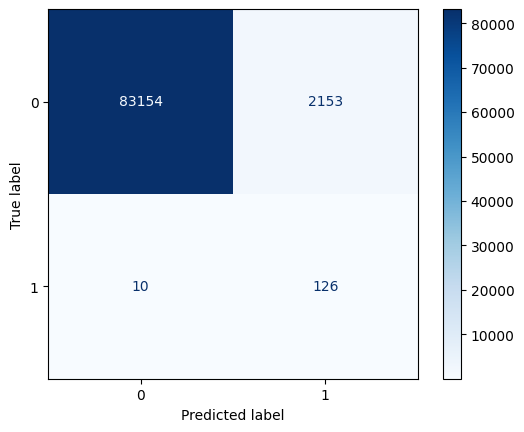

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap='Blues')

**Precision - Recall Curve (Due to imbalanced Data**)

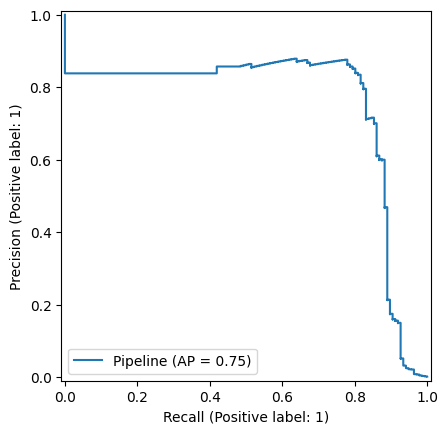

In [50]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(lrg,X_test,y_test)

# ============================================================
# PHASE 4: Modeling
# and
# PHASE 5: Evaluation
# ============================================================

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/tmp/ipykernel_170/614087135.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


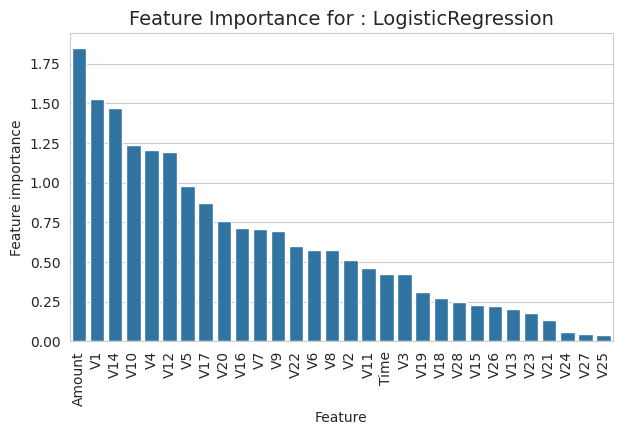

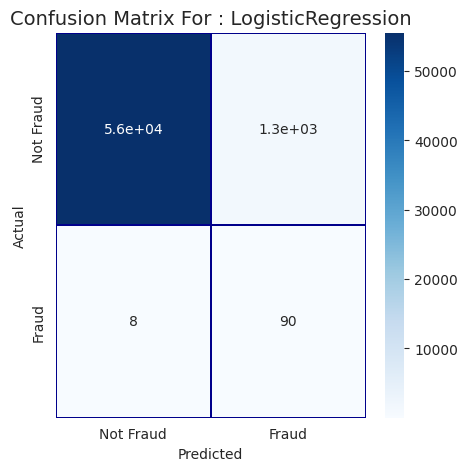

/tmp/ipykernel_170/614087135.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


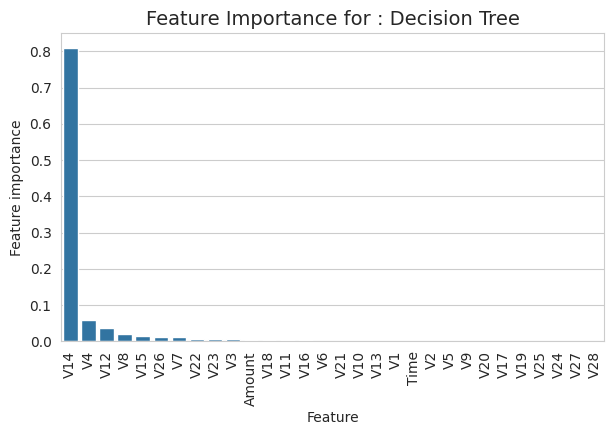

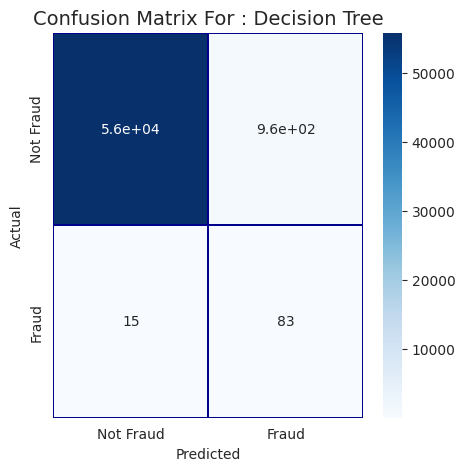

/tmp/ipykernel_170/614087135.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


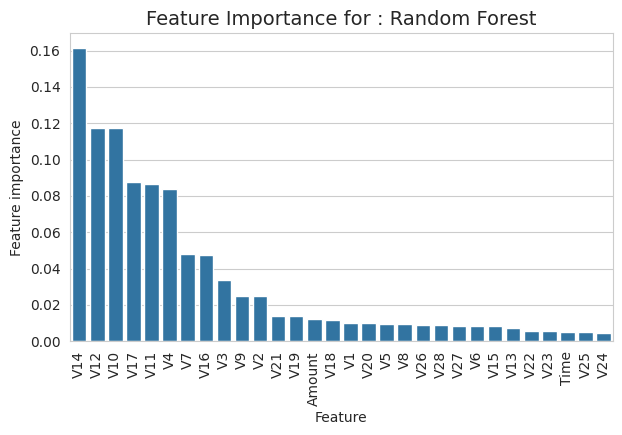

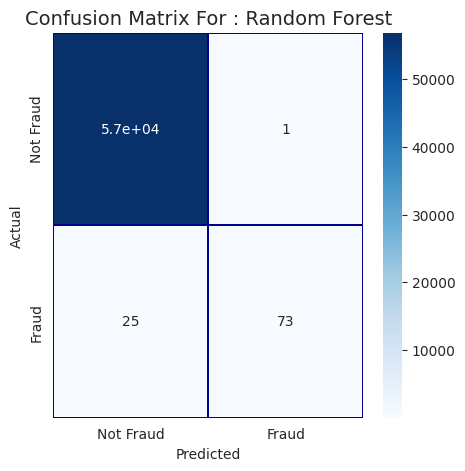

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.120394 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339


/tmp/ipykernel_170/614087135.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  s.set_xticklabels(s.get_xticklabels(),rotation=90)


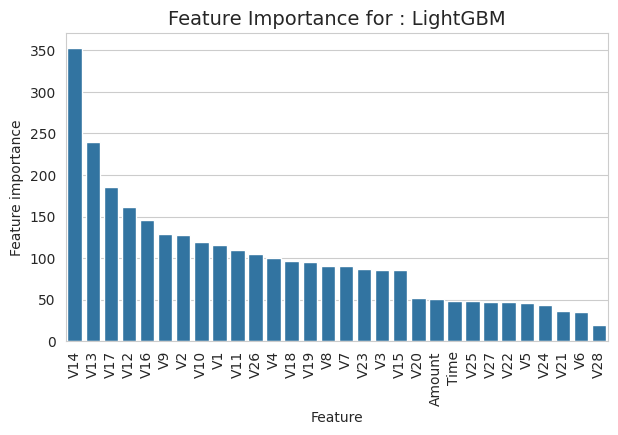

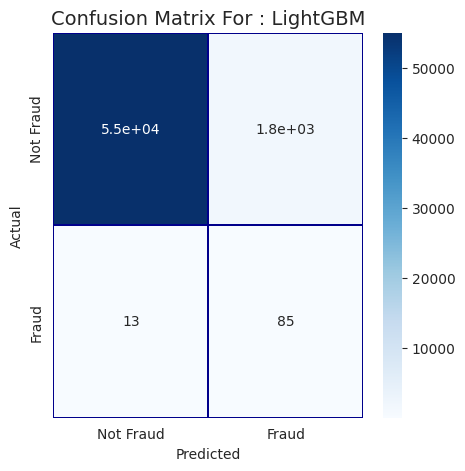

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1-Score
3,Random Forest,0.872440,0.735271,0.999544,0.986486,0.744898,0.848837
2,Decision Tree,0.915002,0.067468,0.982831,0.079350,0.846939,0.145105
1,LogisticRegression,0.947436,0.058102,0.976405,0.063114,0.918367,0.118110
4,LightGBM,0.917793,0.039215,0.968066,0.044950,0.867347,0.085470
0,Dummy,0.500000,0.001720,0.998280,0.000000,0.000000,0.000000


In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score,average_precision_score, accuracy_score, precision_score, recall_score, f1_score


Fraud_classification_Models ={
    'Dummy':DummyClassifier(strategy='most_frequent'),
    'LogisticRegression':Pipeline([('scaler',StandardScaler()),('model',LogisticRegression(class_weight='balanced',random_state=42))]),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced',max_depth=6),
    'Random Forest':RandomForestClassifier(class_weight='balanced',n_estimators=100,n_jobs=4,criterion='gini',verbose=False),
    'LightGBM': lgb.LGBMClassifier(scale_pos_weight=577)
}

results=[]
for name,model in Fraud_classification_Models.items():
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  # Corrected to get probabilities for the positive class (index 1) for all samples
  #y_prob = model.predict_proba(X_test)[:, 1]
  results.append({
      'Model': name, # Changed key to string for easier DataFrame creation
      'ROC-AUC' :roc_auc_score(y_test,y_pred),
      'PR-AUC':average_precision_score(y_test,y_pred),
      'Accuracy':accuracy_score(y_test,y_pred),
      'Precision':precision_score(y_test,y_pred),
      'Recall':recall_score(y_test,y_pred),
      'F1-Score':f1_score(y_test,y_pred)
  })

  feature_importances = None
  feature_names = X_train.columns

  if hasattr(model, 'feature_importances_'):
      feature_importances = model.feature_importances_
  elif isinstance(model, Pipeline) and hasattr(model.named_steps['model'], 'coef_'):
      feature_importances = np.abs(model.named_steps['model'].coef_[0]) # Use absolute coefficients for linear models
  # For DummyClassifier and other models without importances/coefficients, feature_importances remains None

  if feature_importances is not None:
      tmp = pd.DataFrame({'Feature': feature_names, 'Feature importance': feature_importances})
      tmp = tmp.sort_values(by='Feature importance',ascending=False)
      plt.figure(figsize = (7,4))
      plt.title(f'Feature Importance for : {name}',fontsize=14)
      s = sns.barplot(x='Feature',y='Feature importance',data=tmp)
      s.set_xticklabels(s.get_xticklabels(),rotation=90)
      plt.show()

      cm = pd.crosstab(y_test.values, y_pred, rownames=['Actual'], colnames=['Predicted'])
      fig, (ax1) = plt.subplots(ncols=1, figsize=(5,5))
      sns.heatmap(cm,
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'],
            annot=True,ax=ax1,
            linewidths=.2,linecolor="Darkblue", cmap="Blues")
      plt.title(f'Confusion Matrix For : {name}', fontsize=14)
      plt.show()

results_df = pd.DataFrame(results).sort_values('PR-AUC',ascending=False)
results_df